# EDA 
1. Are the labels meaningful?
2. Is there class imbalance?
3. Which features have real signal?
4. Are outliers errors or reality?

## Importing libraries

In [63]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 
import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

warnings.filterwarnings("ignore")

In [64]:
# Loading model tables
df = pd.read_csv("../outputs/model_table.csv")
df.shape

(25000, 20)

In [65]:
# convert data columns
df['registration_date'] = pd.to_datetime(df['registration_date'],errors='coerce')
df['visit_date'] = pd.to_datetime(df['visit_date'],errors='coerce')
df['billing_date'] = pd.to_datetime(df['billing_date'],errors='coerce')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   patient_id            25000 non-null  int64         
 1   age                   25000 non-null  int64         
 2   gender                25000 non-null  str           
 3   city                  25000 non-null  str           
 4   insurance_provider    25000 non-null  str           
 5   chronic_flag          25000 non-null  int64         
 6   registration_date     25000 non-null  datetime64[us]
 7   visit_id              25000 non-null  int64         
 8   visit_date            25000 non-null  datetime64[us]
 9   department            25000 non-null  str           
 10  visit_type            25000 non-null  str           
 11  length_of_stay_hours  25000 non-null  float64       
 12  risk_score            25000 non-null  str           
 13  doctor_id             25000

In [66]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
patient_id,25000.0,NaN,NaN,NaN,2502.20312,1.0,1263.0,2503.0,3755.0,5000.0,1443.378814
age,25000.0,NaN,NaN,NaN,44.89464,1.0,22.0,45.0,67.0,90.0,25.858097
gender,25000,2,M,12732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,25000,6,Bangalore,4328,NaN,NaN,NaN,NaN,NaN,NaN,NaN
insurance_provider,25000,4,HealthPlus,6499,NaN,NaN,NaN,NaN,NaN,NaN,NaN
chronic_flag,25000.0,NaN,NaN,NaN,0.49948,0.0,0.0,0.0,1.0,1.0,0.50001
registration_date,25000,NaN,NaN,NaN,2025-07-20 16:04:30.720000,2025-01-20 00:00:00,2025-04-19 00:00:00,2025-07-18 00:00:00,2025-10-21 00:00:00,2026-01-19 00:00:00,NaN
visit_id,25000.0,NaN,NaN,NaN,12500.5,1.0,6250.75,12500.5,18750.25,25000.0,7217.022701
visit_date,25000,NaN,NaN,NaN,2025-10-20 07:55:39.648000,2025-01-21 00:00:00,2025-09-01 00:00:00,2025-11-12 00:00:00,2025-12-27 00:00:00,2026-01-20 00:00:00,NaN
department,25000,6,General,5757,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Distribution Analysis
## Missing Values Analysis
First thing we always check : What is missing and why

Not all nulls are data errors some are business logic 

In [67]:
# overall null check
df.isnull().sum().sort_values(ascending=False)

payment_days            9532
approved_amount         6156
patient_id                 0
age                        0
city                       0
gender                     0
insurance_provider         0
chronic_flag               0
visit_date                 0
department                 0
registration_date          0
visit_id                   0
length_of_stay_hours       0
visit_type                 0
risk_score                 0
doctor_id                  0
billed_amount              0
bill_id                    0
claim_status               0
billing_date               0
dtype: int64

In [68]:
# Focus on key columns
df[['approved_amount','payment_days','length_of_stay_hours']].isnull().sum()

approved_amount         6156
payment_days            9532
length_of_stay_hours       0
dtype: int64

## Step 2 - Business Logic Validation

In [69]:
# check A- Paid claims should always have an approved ampunt
# if this returns 0 we are clean
df[
    (df['claim_status'] == 'Paid') &
    (df['approved_amount'].isna())
].shape

(0, 20)

In [70]:
# Check B - payment days missing breakdown by claim status
df[df['payment_days'].isna()]['claim_status'].value_counts()

claim_status
Rejected    5266
Pending     4266
Name: count, dtype: int64

for pending and rejected claim statuses we can expect the payment days to be null, hoewever for Paid claim status it should not be null and should have a value

In [71]:
# Check C - LOS should never be negative
(df['length_of_stay_hours']<0).sum()

np.int64(0)

## Step 3 - Distribution Analysis

In [72]:
# categorical column reports
print("========== Department ============")
print(df['department'].value_counts())
print("\n============ Visit type=========")
print(df['visit_type'].value_counts())
print("\n============ Insurance Provider============")
print(df['insurance_provider'].value_counts())
print("\n============City==================")
print(df['city'].value_counts())

========== Department ============
department
General        5757
Orthopedics    4474
Cardiology     4071
ER             3896
ICU            3415
Neurology      3387
Name: count, dtype: int64

============ Visit type=========
visit_type
OPD    14635
ER      5778
ICU     4587
Name: count, dtype: int64

============ Insurance Provider============
insurance_provider
HealthPlus    6499
CareOne       6326
SecureLife    6197
MediCareX     5978
Name: count, dtype: int64

============City==================
city
Bangalore    4328
Mumbai       4267
Pune         4230
Delhi        4170
Hyderabad    4129
Chennai      3876
Name: count, dtype: int64


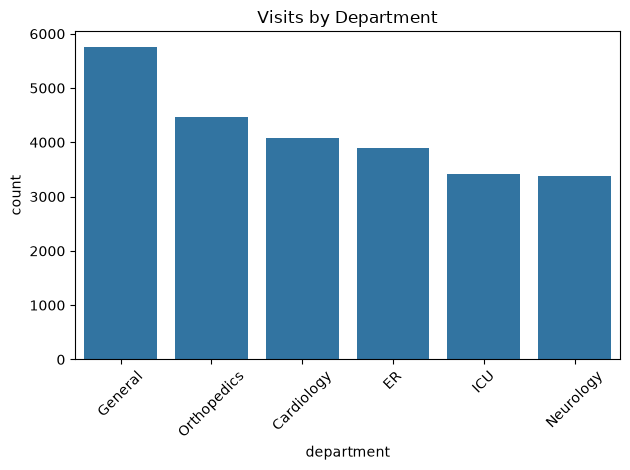

In [73]:
# bar chart showing visits by department
sns.countplot(data=df,x='department',order=df['department'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Visits by Department")
plt.tight_layout()
plt.show()

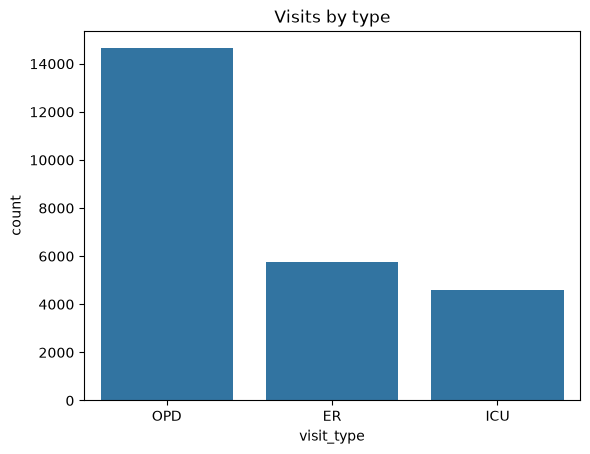

In [74]:
# visits by type
sns.countplot(data=df,x="visit_type",order=df['visit_type'].value_counts().index)
plt.title("Visits by type")
plt.show()

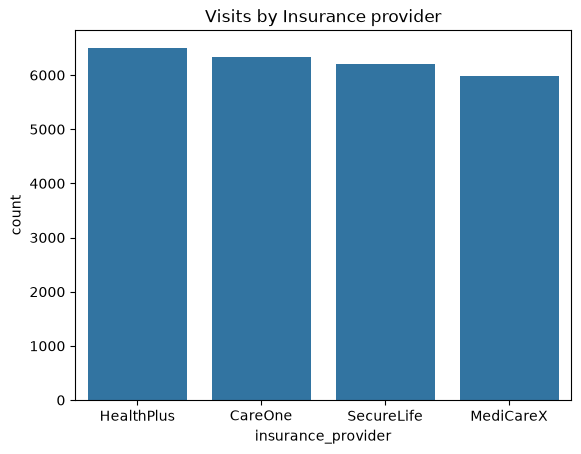

In [75]:
# visits by Insurance provider
sns.countplot(data=df,x="insurance_provider",order=df['insurance_provider'].value_counts().index)
plt.title("Visits by Insurance provider")
plt.show()

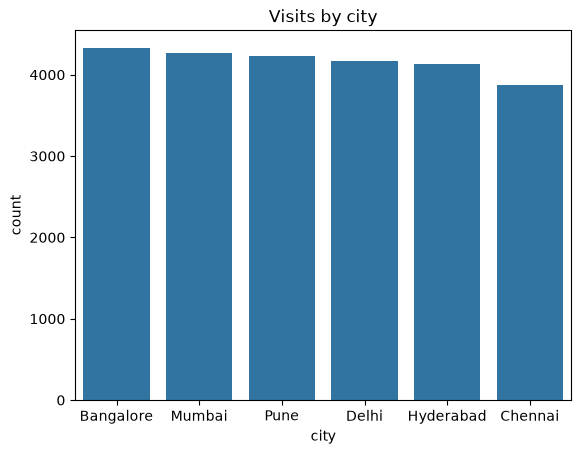

In [76]:
# Visits by City
sns.countplot(data=df,x="city",order=df['city'].value_counts().index)
plt.title("Visits by city")
plt.show()

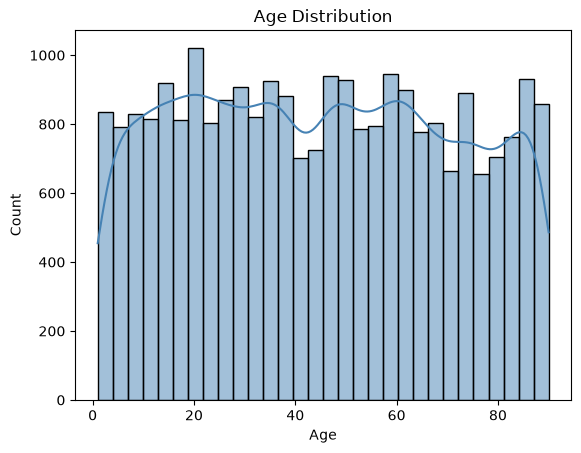

count    25000.00
mean        44.89
std         25.86
min          1.00
25%         22.00
50%         45.00
75%         67.00
max         90.00
Name: age, dtype: float64


In [77]:
# Age distribution
sns.histplot(df['age'],bins=30,kde=True,color='steelblue')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()
print(df['age'].describe().round(2))

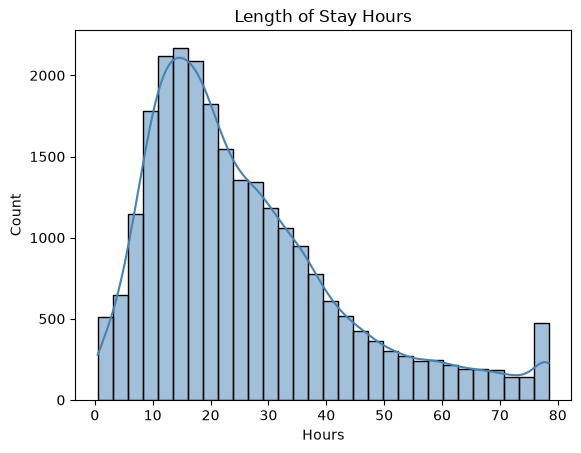

count    25000.00
mean        26.03
std         17.15
min          0.50
25%         13.54
50%         21.61
75%         34.22
max         78.42
Name: length_of_stay_hours, dtype: float64


In [78]:
# Length of stay distribution
sns.histplot(df['length_of_stay_hours'],bins=30,kde=True,color='steelblue')
plt.title("Length of Stay Hours")
plt.xlabel("Hours")
plt.show()
print(df['length_of_stay_hours'].describe().round(2))

most patients stay for shorter hours we can see that most of them are clustered in the 0-30 hours. We have a right skew in this case

In [79]:
# IQR for LOS
# 25% = 9.96 (bottom quarter boundary)
# 75% = 27.31 (top quarter boundary)
IQR = 27.31 - 9.96
print(IQR)

17.349999999999998


In [80]:
# Upper Fence
# An upper fence is bthe cutoff beyond which a value is considered to be am outlier
#upper_fence = 75% + (1.5*IQR)
upper_fence = 27.31 + (1.5*17.35)
print(upper_fence)

53.335


## Outlier Detection
**Two approaches:**
- Boxplot - visual detection
- IQR method - numerical calculation


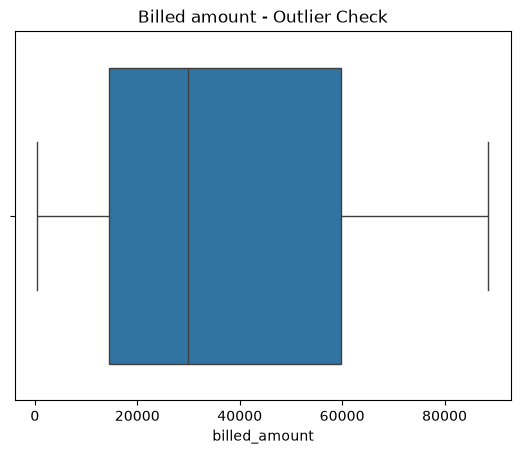

In [81]:
sns.boxplot(x=df['billed_amount'])
plt.title("Billed amount - Outlier Check")
plt.show()

Beyond approximately 55000 bills is what we consider outliers with a few whiskers that reach even above 80000 (possibly for longer surgeries and complex medical procidures)

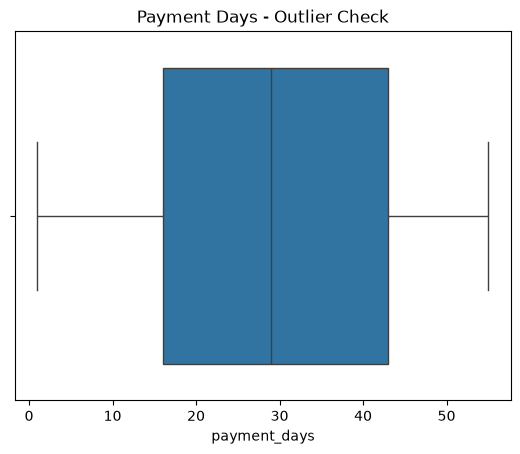

In [82]:
sns.boxplot(x=df['payment_days'])
plt.title("Payment Days - Outlier Check")
plt.show()

Most bills are payed within 17 days. The dots crossing past 30 and stretching towards around 55 are the outlier payments (insurers that take over a month to pay)

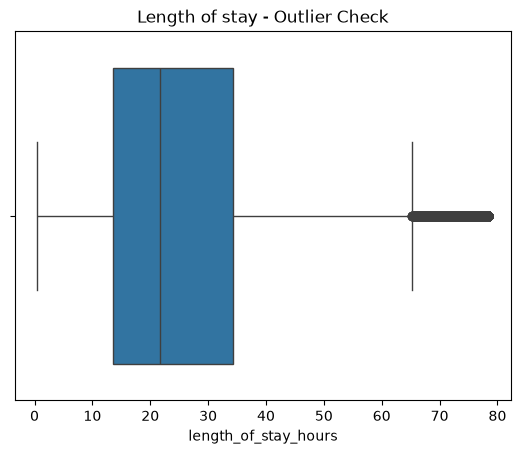

In [83]:
sns.boxplot(x=df['length_of_stay_hours'])
plt.title("Length of stay - Outlier Check")
plt.show()

similar to payment days and billed amount this box plot also shows outliers in the right tail. This chart also matches the previously calculated upper fence where outliers are in the values above the upper fence

In [84]:
# IQR explicit calculation - numbers behind box plot
for col in ['length_of_stay_hours','billed_amount','payment_days']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3-Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    n_out = ((df[col] <lower) | (df[col] > upper)).sum()

    print(f"{col}")
    print(f"Q1 = {Q1:.1f} | Q3 = {Q3:.1f} | IQR = {IQR:.1f}")
    print(f"   Lower bound = {lower:.1f} | Upper bound = {upper:.1f}")
    print(f"  Outliers = {n_out} rows")
    print()


length_of_stay_hours
Q1 = 13.5 | Q3 = 34.2 | IQR = 20.7
   Lower bound = -17.5 | Upper bound = 65.2
  Outliers = 1136 rows

billed_amount
Q1 = 14568.7 | Q3 = 59710.5 | IQR = 45141.8
   Lower bound = -53144.0 | Upper bound = 127423.3
  Outliers = 0 rows

payment_days
Q1 = 16.0 | Q3 = 43.0 | IQR = 27.0
   Lower bound = -24.5 | Upper bound = 83.5
  Outliers = 0 rows



## Feature Correlations 
**We encode the target variables numerically so we can measure correlation**
- risk_score -> Low=0, Meduim=1,High=2
- claim_status -> Paid=0,Pending=1,Rejected=2

In [85]:
# Encode target for correlation analysis
df['risk_numeric'] = df['risk_score'].map(
    {"Low:":0,"Meduim":1,"High":2}
)
df["claim_numeric"] = df['claim_status'].map(
    {"Paid":0,"Pending":1,"Rejected":2}
)
print("risk numeric :", {"Low:":0,"Meduim":1,"High":2})
print("claim numeric: ",{"Paid":0,"Pending":1,"Rejected":2})

risk numeric : {'Low:': 0, 'Meduim': 1, 'High': 2}
claim numeric:  {'Paid': 0, 'Pending': 1, 'Rejected': 2}


In [86]:
df['risk_numeric']

0        NaN
1        2.0
2        2.0
3        NaN
4        NaN
        ... 
24995    NaN
24996    NaN
24997    NaN
24998    NaN
24999    NaN
Name: risk_numeric, Length: 25000, dtype: float64

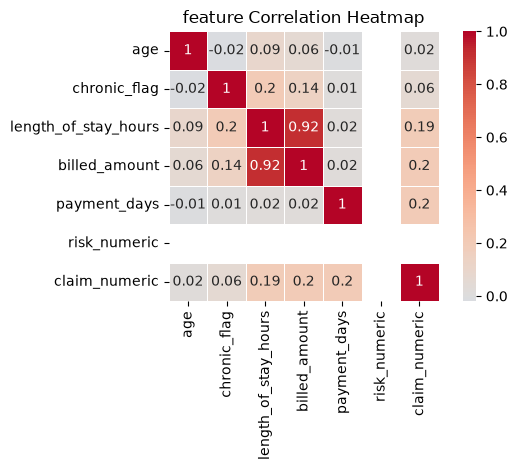

In [87]:
# full correlation heatmap
numerical_cols = [
    "age",
    "chronic_flag",
    "length_of_stay_hours",
    "billed_amount",
    "payment_days",
    "risk_numeric",
    "claim_numeric"
]
corr = df[numerical_cols].corr().round(2)
sns.heatmap(corr,annot=True,cmap="coolwarm",center=0,linewidth=0.5,square=True)
plt.title("feature Correlation Heatmap")
plt.tight_layout()
plt.show()

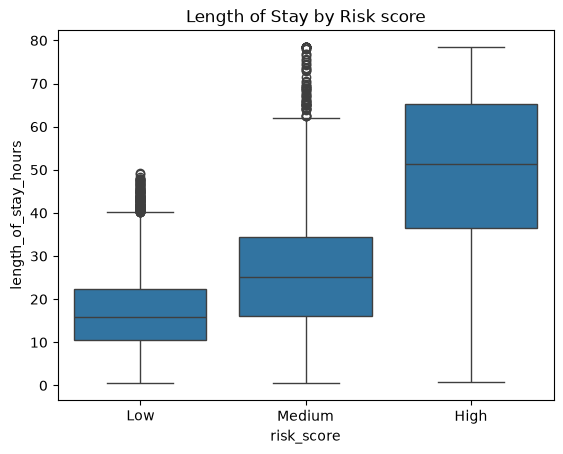


 Mean LOS by Risk Score:
risk_score
High      50.69
Low       16.92
Medium    26.10
Name: length_of_stay_hours, dtype: float64


In [88]:
# LOS by risk score
sns.boxplot(data=df,x="risk_score",y="length_of_stay_hours",order=['Low','Medium','High'])
plt.title("Length of Stay by Risk score")
plt.show()

print("\n Mean LOS by Risk Score:")
print(df.groupby("risk_score")['length_of_stay_hours'].mean().round(2))

Rejection Rate by Insurance Provider (%):
insurance_provider
CareOne       25.7
MediCareX     24.3
HealthPlus    18.7
SecureLife    15.7
Name: is_rejected, dtype: float64


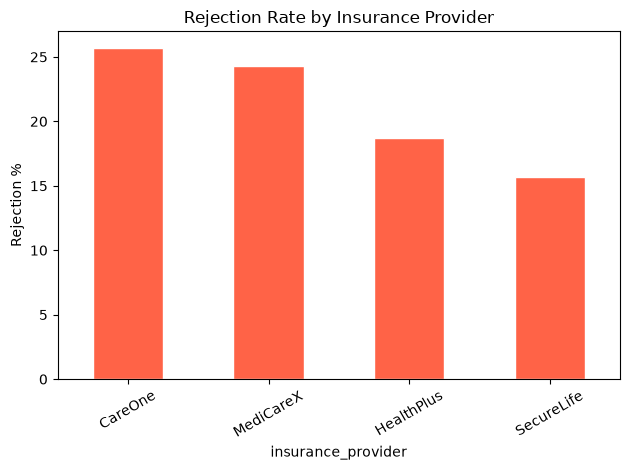

In [89]:
# Rejection by insurance provider
df['is_rejected'] = (df['claim_status'] == "Rejected").astype(int)

rej_rate = (df.groupby("insurance_provider")["is_rejected"].mean()
            .sort_values(ascending=False)
            .mul(100)
            .round(1))

print("Rejection Rate by Insurance Provider (%):")
print(rej_rate)

rej_rate.plot(kind="bar",color="tomato",edgecolor="white")
plt.title("Rejection Rate by Insurance Provider")
plt.ylabel("Rejection %")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Class Imbalance Deep Dive
**Class Imbalance**
- Class Imbalance
- Class collapse

In [90]:
# Naive baseline - what happens if we always predict the majority class

most_common = df['risk_score'].mode()[0]
naive_acc = (df['risk_score'] == most_common).mean()
print(f"Majority class: {most_common}")
print(f"Naive Accuracy : {naive_acc:.1%}")

Majority class: Low
Naive Accuracy : 46.9%


In [91]:
# Demo setup - 2 features only, to keep it clean
X_demo = df[['length_of_stay_hours','chronic_flag']].fillna(0)
y_demo = df["risk_score"]

# without class weight
model_bad = LogisticRegression(max_iter=1000,random_state=42)
model_bad.fit(X_demo,y_demo)
pred_bad = model_bad.predict(X_demo)
print("Without class weight = 'balanced'")
print("-"*45)
print(classification_report(y_demo,pred_bad))

# model trained with class weights = balanced
model_good = LogisticRegression(max_iter=1000,random_state=42,class_weight='balanced')
model_good.fit(X_demo,y_demo)
pred_good = model_good.predict(X_demo)
print("With class weight = 'balanced'")
print("-"*45)
print(classification_report(y_demo,pred_good))

Without class weight = 'balanced'
---------------------------------------------
              precision    recall  f1-score   support

        High       0.78      0.63      0.69      4316
         Low       0.72      0.78      0.75     11735
      Medium       0.56      0.55      0.56      8949

    accuracy                           0.67     25000
   macro avg       0.69      0.65      0.67     25000
weighted avg       0.67      0.67      0.67     25000

With class weight = 'balanced'
---------------------------------------------
              precision    recall  f1-score   support

        High       0.62      0.74      0.67      4316
         Low       0.76      0.71      0.73     11735
      Medium       0.54      0.54      0.54      8949

    accuracy                           0.65     25000
   macro avg       0.64      0.66      0.65     25000
weighted avg       0.66      0.65      0.65     25000



## Feature Engineering
We create 7 new features from the existing columns. These features encode patient behaviour and provider patterns that the raw columns cannot express on their own. 
|       Feature           |             Logic                |        Why it matters                  |
| ----------------------  | -------------------------------- | ---------------------------------------|
| days since registration | visits_date - registration-date  | Long-term patients behave differently  |
|     visit_frequency     | count of visits per patient      | Frequent visitors = higher utilisation |
|   avg_los_per_patient   | mean LOS per patient             | Patient-level healthcare baseline      |
|       is_rejected       | 1 if Rejected else 0             | Helper for rejection rate              |
| provider_rejection_rate | mean rejection per insurer       | Encodes insurer behaviour              |
|       visit_month       | month from visit_date            | Seasonality signal                     |
|     visit_dayofweek     | day of week from visit_date      | Operational pattern                    |
|  high_cost_visit_flag   | billed > 75th percentile         | Flags expensive visits                 |

In [92]:
# days since registration
df['days_since_registration'] = abs(
    df['visit_date'] - df['registration_date']
).dt.days

df[['patient_id','visit_date','registration_date','days_since_registration']].head()

,patient_id,visit_date,registration_date,days_since_registration
0,2,2026-01-01,2025-12-27,5
1,12,2026-01-01,2025-08-13,141
2,129,2026-01-01,2025-07-20,165
3,133,2026-01-01,2025-11-02,60
4,139,2026-01-01,2025-02-05,330


In [93]:
# visit frequency per patient
df['visit_frequency'] = df.groupby('patient_id')['visit_id'].transform("count")

df[['patient_id','visit_frequency']].drop_duplicates().head(10)

,patient_id,visit_frequency
0,2,4
1,12,8
2,129,3
3,133,3
4,139,9
5,170,6
6,216,5
7,222,5
8,243,9
9,335,5


In [94]:
# Average LOS per patient
df['avg_los_per_patient'] = df.groupby('patient_id')['length_of_stay_hours'].transform("mean")
df[['patient_id','length_of_stay_hours','avg_los_per_patient']].head()

,patient_id,length_of_stay_hours,avg_los_per_patient
0,2,9.63,21.120000
1,12,59.60,23.750000
2,129,59.28,32.460000
3,133,25.15,30.056667
4,139,42.88,29.030000


In [95]:
# provider rejection rate
df["provider_rejection_rate"] = df.groupby("insurance_provider")["is_rejected"].transform("mean")

print("Rejection rate per provider:")
print(df.groupby("insurance_provider")["provider_rejection_rate"]
      .first().round(3))

Rejection rate per provider:
insurance_provider
CareOne       0.257
HealthPlus    0.187
MediCareX     0.243
SecureLife    0.157
Name: provider_rejection_rate, dtype: float64


In [96]:
# Time-based features
df['visit_month'] = df['visit_date'].dt.month
df['visit_dayofweek'] = df['visit_date'].dt.dayofweek

df[['visit_date','visit_month','visit_dayofweek']].head()

,visit_date,visit_month,visit_dayofweek
0,2026-01-01,1,3
1,2026-01-01,1,3
2,2026-01-01,1,3
3,2026-01-01,1,3
4,2026-01-01,1,3


In [97]:
# High cost visit flag - top 25% of billed amount
high_cost_threshold = df['billed_amount'].quantile(0.75)
df['high_cost_visit_flag'] = (df['billed_amount'] > high_cost_threshold.astype(int))

print(f"High cosy threshold (75th percentile): {high_cost_threshold:,.0f}")
print()
print(df['high_cost_visit_flag'].value_counts())

High cosy threshold (75th percentile): 59,711

high_cost_visit_flag
False    18749
True      6251
Name: count, dtype: int64


In [98]:
# Final feature check
new_features = [
    "days_since_registration",
    "visit_frequency",
    "avg_los_per_patient",
    "provider_rejection_rate",
    "visit_month",
    "visit_dayofweek",
    "high_cost_visit_flag"
]

print("New features added:")
for f in new_features:
    print(f"  ✓ {f}")

print(f"\nFinal dataset shape: {df.shape}")

New features added:
  ✓ days_since_registration
  ✓ visit_frequency
  ✓ avg_los_per_patient
  ✓ provider_rejection_rate
  ✓ visit_month
  ✓ visit_dayofweek
  ✓ high_cost_visit_flag

Final dataset shape: (25000, 30)


In [99]:
df[new_features].describe().round(2)

,days_since_registration,visit_frequency,avg_los_per_patient,provider_rejection_rate,visit_month,visit_dayofweek
count,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00
mean,91.66,6.04,26.03,0.21,7.57,2.98
std,80.65,2.39,8.48,0.04,4.10,2.02
min,1.00,1.00,0.50,0.16,1.00,0.00
25%,25.00,4.00,20.06,0.19,4.00,1.00
50%,69.00,6.00,25.13,0.19,9.00,3.00
75%,140.00,8.00,30.82,0.26,11.00,5.00
max,363.00,14.00,78.42,0.26,12.00,6.00


In [100]:
# Save enriched model_table — ready for Phase 3 Modeling
df.to_csv("../outputs/model_table.csv", index=False)

print("model_table.csv saved ✓")
print(f"Shape  : {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print("\nReady for Phase 3 — Modeling")

model_table.csv saved ✓
Shape  : (25000, 30)
Columns: ['patient_id', 'age', 'gender', 'city', 'insurance_provider', 'chronic_flag', 'registration_date', 'visit_id', 'visit_date', 'department', 'visit_type', 'length_of_stay_hours', 'risk_score', 'doctor_id', 'bill_id', 'billed_amount', 'approved_amount', 'claim_status', 'payment_days', 'billing_date', 'risk_numeric', 'claim_numeric', 'is_rejected', 'days_since_registration', 'visit_frequency', 'avg_los_per_patient', 'provider_rejection_rate', 'visit_month', 'visit_dayofweek', 'high_cost_visit_flag']

Ready for Phase 3 — Modeling
